In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [2]:
from scipy.stats import mode
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

In [3]:


from imblearn.over_sampling import SMOTE
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
import pandas as pd

data =pd.read_csv("final_dataset_PART1.csv")

print(f'Dataset Shape: {data.shape}')
print(f' Dataset Memory Usage: {data.memory_usage().sum() / 1024 ** 2:.2f} MB')

Dataset Shape: (1976, 62)
 Dataset Memory Usage: 0.43 MB


In [6]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 44.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 65.6 MB/s eta 0:00:0000:0100:01


In [7]:
!pip install -U xgboost
!pip install -U scikit-learn


#### Predopovedanie doby prezitia pacientov

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error


# Zakódujeme všetky kategorizované (object) atribúty na číselné hodnoty
for column in data.select_dtypes(include=['object', 'category']).columns:
    data[column] = data[column].astype('category').cat.codes

# Rozdelenie dát na vstupné atribúty (X) a cieľovú premennú (y)
X = data.drop(columns=['time'])  # Všetky atribúty okrem 'time'
y = data['time']  # Cieľová premenná

# Stratifikácia: Rozdelenie y do kategórií (napr. kvartily)
y_strat = pd.qcut(y, q=4, labels=False)

# Stratifikované rozdelenie na tréningové a testovacie dáta
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y_strat
)

# Vytvorenie DMatrix pre XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Nastavenie parametrov pre model XGBoost
params = {
    'objective': 'reg:squarederror',  # Pre regresiu
    'eval_metric': 'rmse',             # Hodnotenie modelu
    'max_depth': 6,                     # Maximálna hĺbka stromu
    'eta': 0.1,                         # Rýchlosť učenia
    'subsample': 0.8,                   # Podmnožina vzoriek
    'colsample_bytree': 0.8             # Podmnožina atribútov
}

# Trénovanie modelu
model1 = xgb.train(params, dtrain, num_boost_round=100)

# Predikcia na testovacích dátach
y_pred1 = model1.predict(dtest)

# Vyhodnotenie modelu
mse = mean_squared_error(y_test, y_pred1)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 663.3310842923094


In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Vypočítajte metriky
mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² score: {r2:.2f}")

Mean Absolute Error (MAE): 14.76
Mean Squared Error (MSE): 663.33
R² score: 0.89


###  Experiment s dôležitosťou atribútov v XGBoost
###### Využijeme zabudovanú dôležitosť atribútov (feature_importances_), ktorú ponúka XGBoost, na identifikáciu najdôležitejších atribútov. Môžeš vykresliť graf atribútov, ktorý ukáže ich vplyv:


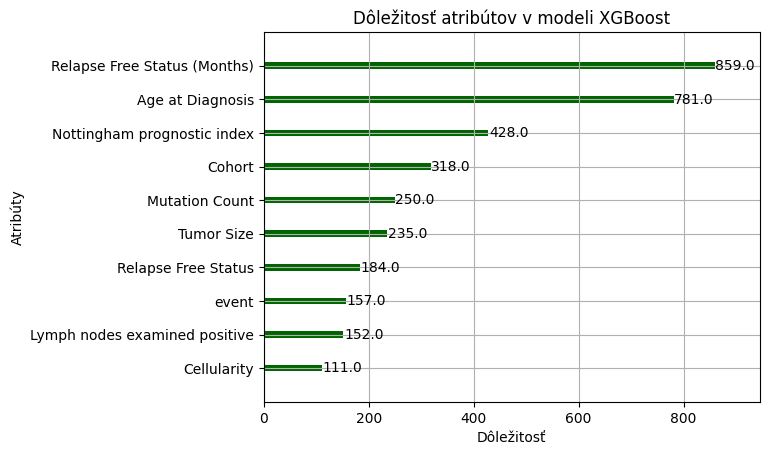

In [10]:
# Experiment s dôležitosťou atribútov
xgb.plot_importance(model1, importance_type='weight', max_num_features=10, color = "darkgreen")
plt.title('Dôležitosť atribútov v modeli XGBoost')
plt.xlabel('Dôležitosť')
plt.ylabel('Atribúty')
plt.show()

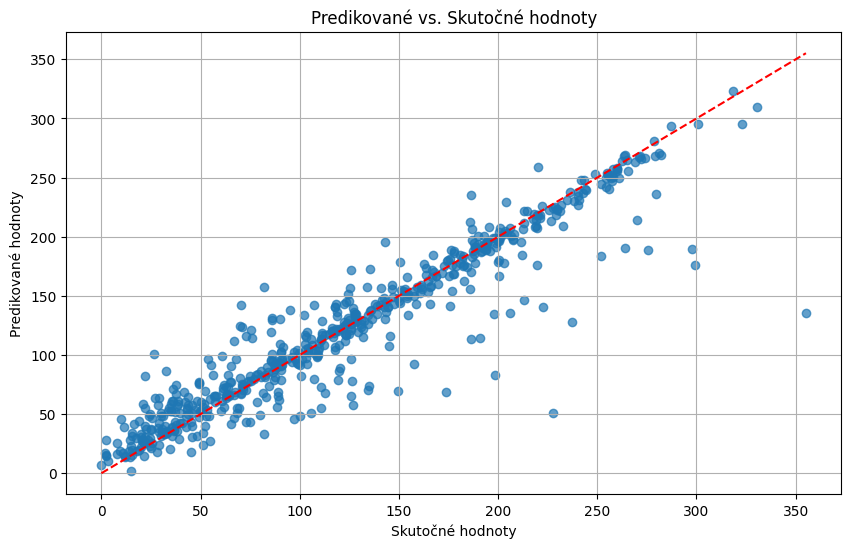

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred1, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Predikované vs. Skutočné hodnoty')
plt.xlabel('Skutočné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.grid()
plt.show()

### Vyuzijeme na predpovedanie atributy z Cox regresie (Analyticky proces 1.cast)

In [12]:
# Rozdelenie dát na vstupné atribúty a cieľovú premennú (time)
X = data[[
    'event',
    'Age at Diagnosis',
    'Chemotherapy',
    'Cohort',
    'ER Status',
    'HER2 Status',
    'Nottingham prognostic index',
    'Relapse Free Status (Months)', 
    'Tumor Stage'
]]

# Cieľová premenná (doba prežitia)
y = data['time']

# Stratifikácia: Rozdelenie y do kategórií (napr. kvartily)
y_strat = pd.qcut(y, q=4, labels=False)

# Stratifikované rozdelenie na tréningové a testovacie dáta
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y_strat
)

# Vytvorenie DMatrix pre XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Nastavenie parametrov pre model XGBoost
params = {
    'objective': 'reg:squarederror',  # Pre regresiu
    'eval_metric': 'rmse',             # Hodnotenie modelu
    'max_depth': 6,                     # Maximálna hĺbka stromu
    'eta': 0.1,                         # Rýchlosť učenia
    'subsample': 0.8,                   # Podmnožina vzoriek
    'colsample_bytree': 0.8             # Podmnožina atribútov
}

# Trénovanie modelu
model = xgb.train(params, dtrain, num_boost_round=100)

# Predikcia na testovacích dátach
y_pred = model.predict(dtest)

# Vyhodnotenie modelu
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 1074.8531899132668


In [13]:
# Vypočítajte metriky
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² score: {r2:.2f}")

Mean Absolute Error (MAE): 17.77
Mean Squared Error (MSE): 1074.85
R² score: 0.81


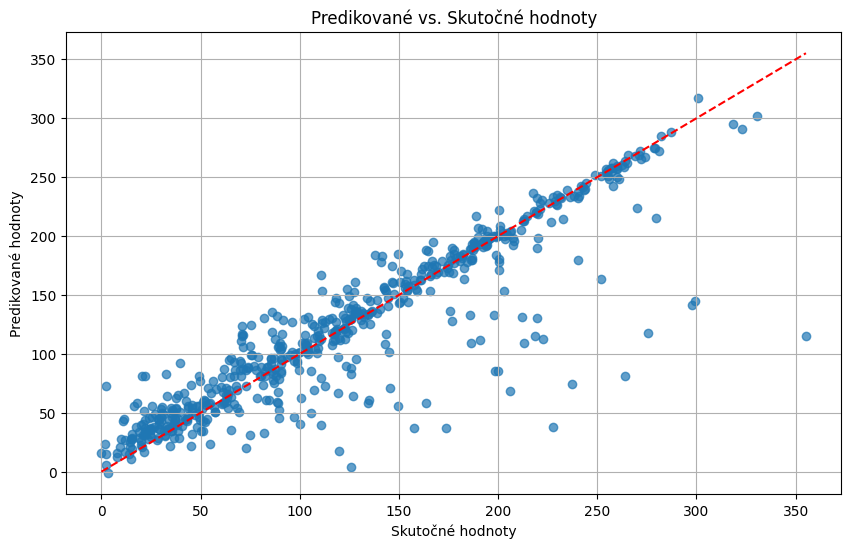

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Predikované vs. Skutočné hodnoty')
plt.xlabel('Skutočné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.grid()
plt.show()


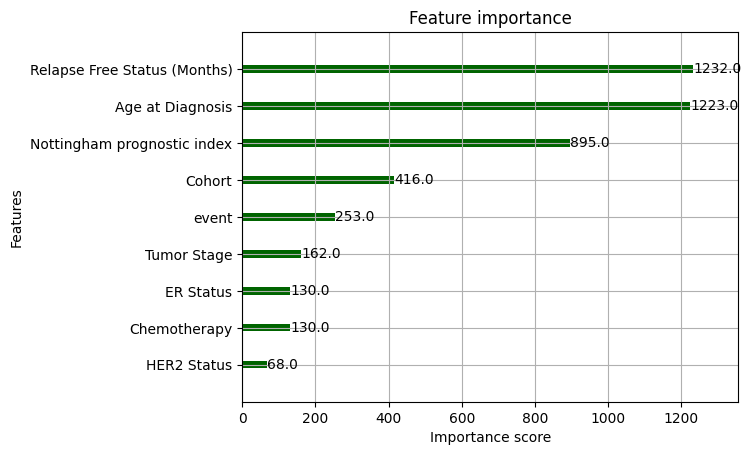

In [15]:

xgb.plot_importance(model, importance_type='weight', max_num_features=10, color = "darkgreen")
plt.show()
